In [5]:
!pip3 install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 18.2 MB/s eta 0:00:0000:0100:01


Shape: (569, 6)

Class Distribution:
 target
1    357
0    212
Name: count, dtype: int64

Statistical Summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness      target  
count       569.000000  569.000000  
mean          0.096360    0.627417  
std           0.014064    0.483918  
min           0.052630    0.000000  
25%           0.086370    0.000000  
50%           0.095870    1.000000  
75%           0.105300    1.000000  
max   

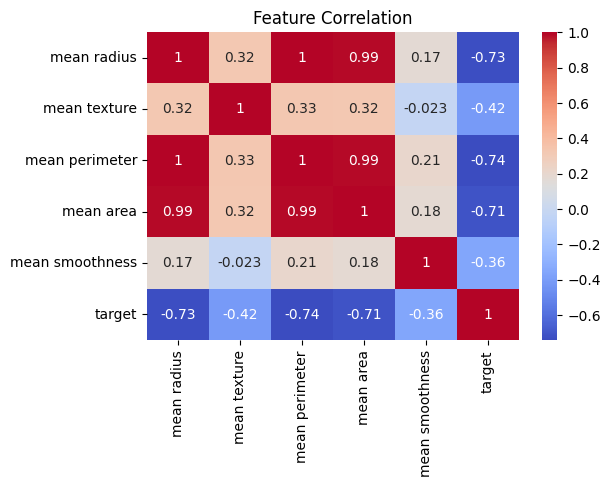

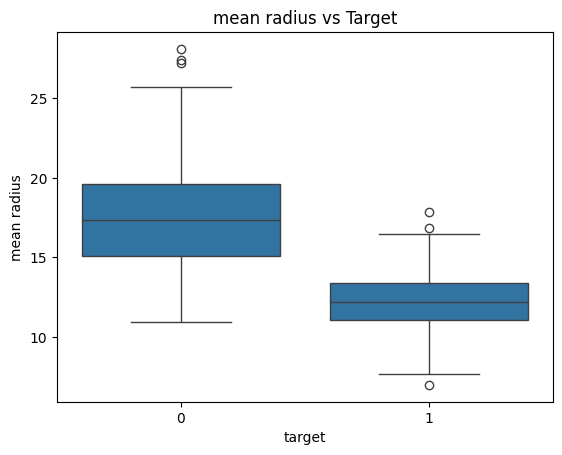


Accuracy: 0.8947368421052632

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.87        42
           1       0.95      0.88      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114


Confusion Matrix:
 [[39  3]
 [ 9 63]]

ROC-AUC: 0.9017857142857143


<Figure size 600x400 with 0 Axes>

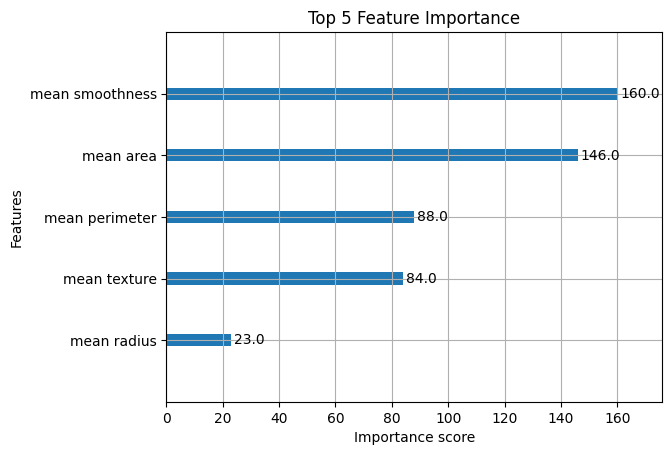

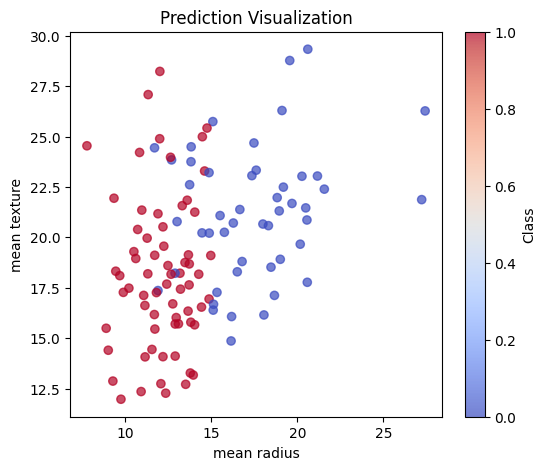

In [21]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ==========================================
# 2. Load Dataset
# ==========================================
data = load_breast_cancer()

# Select only 5 important features
selected_features = [0, 1, 2, 3, 4]

X = data.data[:, selected_features]
y = data.target

feature_names = data.feature_names[selected_features]

# Convert to DataFrame (for analysis)
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# ==========================================
# 3. Basic Insights
# ==========================================
print("Shape:", df.shape)
print("\nClass Distribution:\n", df['target'].value_counts())
print("\nStatistical Summary:\n", df.describe())

# ==========================================
# 4. Data Visualization
# ==========================================

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Boxplot (example)
sns.boxplot(x='target', y=feature_names[0], data=df)
plt.title(f"{feature_names[0]} vs Target")
plt.show()

# ==========================================
# 5. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 6. Model Training
# ==========================================
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# 7. Predictions
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# 8. Evaluation
# ==========================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred))

# ==========================================
# 9. Feature Importance
# ==========================================
plt.figure(figsize=(6,4))
xgb.plot_importance(
    model,
    max_num_features=5,
    importance_type="weight",
    show_values=True
)

plt.yticks(np.arange(5), feature_names)
plt.title("Top 5 Feature Importance")
plt.show()

# ==========================================
# 10. 2D Visualization
# ==========================================
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Prediction Visualization")

plt.colorbar(label="Class")
plt.show()

Shape: (569, 6)

Class Distribution:
 target
1    357
0    212
Name: count, dtype: int64

Statistical Summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness      target  
count       569.000000  569.000000  
mean          0.096360    0.627417  
std           0.014064    0.483918  
min           0.052630    0.000000  
25%           0.086370    0.000000  
50%           0.095870    1.000000  
75%           0.105300    1.000000  
max   

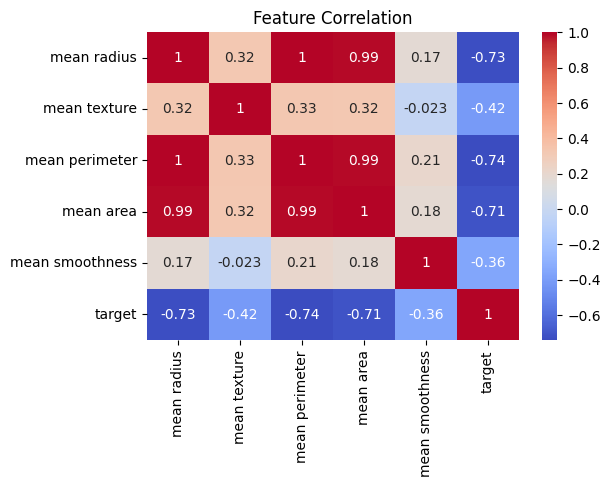

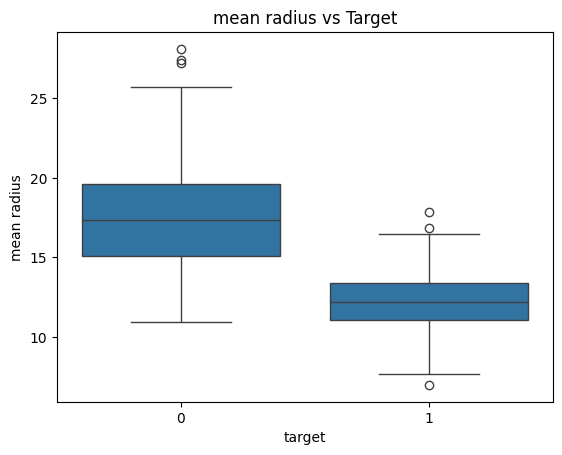


Accuracy: 0.8947368421052632

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.87        42
           1       0.95      0.88      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114


Confusion Matrix:
 [[39  3]
 [ 9 63]]

ROC-AUC: 0.9017857142857143


<Figure size 600x400 with 0 Axes>

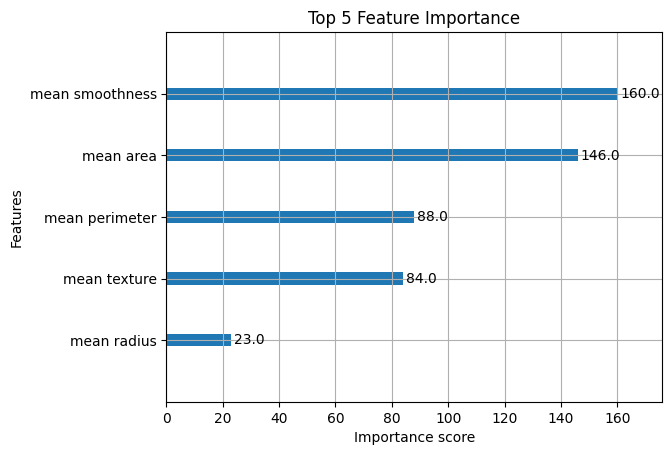

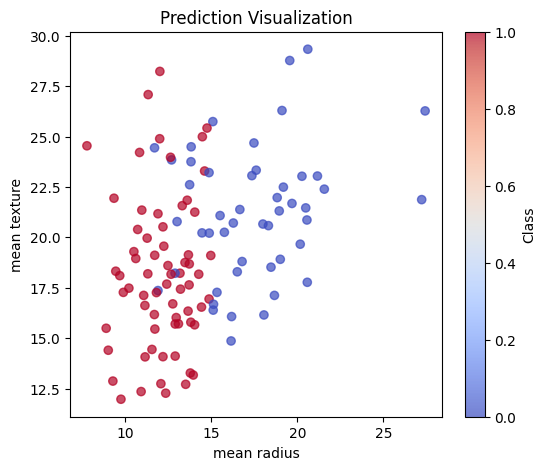

In [21]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score     # ROC → Receiver Operating Characteristic ,AUC → Area Under Curve
)

# ==========================================
# 2. Load Dataset
# ==========================================
data = load_breast_cancer()

# Select only 5 important features
selected_features = [0, 1, 2, 3, 4]

X = data.data[:, selected_features]
y = data.target

feature_names = data.feature_names[selected_features]

# Convert to DataFrame (for analysis)
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# ==========================================
# 3. Basic Insights
# ==========================================
print("Shape:", df.shape)
print("\nClass Distribution:\n", df['target'].value_counts())
print("\nStatistical Summary:\n", df.describe())

# ==========================================
# 4. Data Visualization
# ==========================================

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Boxplot (example)
sns.boxplot(x='target', y=feature_names[0], data=df)
plt.title(f"{feature_names[0]} vs Target")
plt.show()

# ==========================================
# 5. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 6. Model Training
# ==========================================
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# 7. Predictions
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# 8. Evaluation
# ==========================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred))

# ==========================================
# 9. Feature Importance
# ==========================================
plt.figure(figsize=(6,4))
xgb.plot_importance(
    model,
    max_num_features=5,
    importance_type="weight",
    show_values=True
)

plt.yticks(np.arange(5), feature_names)
plt.title("Top 5 Feature Importance")
plt.show()

# ==========================================
# 10. 2D Visualization
# ==========================================
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Prediction Visualization")

plt.colorbar(label="Class")
plt.show()

Shape: (569, 6)

Class Distribution:
 target
1    357
0    212
Name: count, dtype: int64

Statistical Summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness      target  
count       569.000000  569.000000  
mean          0.096360    0.627417  
std           0.014064    0.483918  
min           0.052630    0.000000  
25%           0.086370    0.000000  
50%           0.095870    1.000000  
75%           0.105300    1.000000  
max   

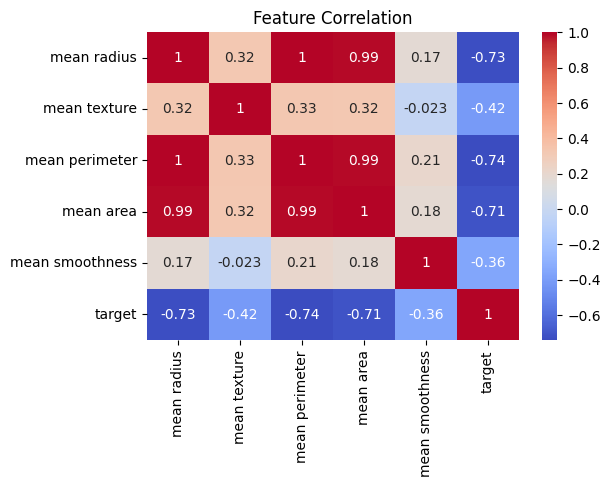

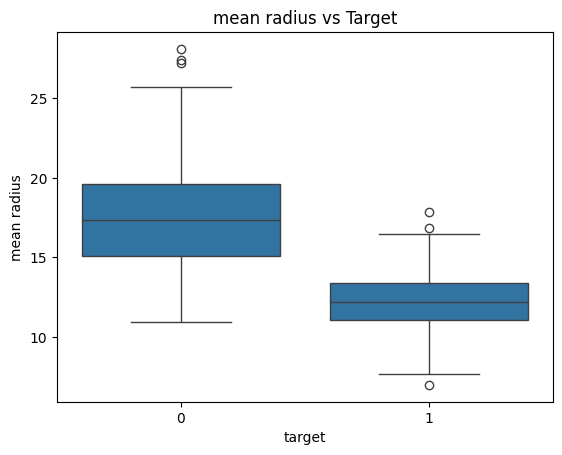


Accuracy: 0.8947368421052632

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.87        42
           1       0.95      0.88      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114


Confusion Matrix:
 [[39  3]
 [ 9 63]]

ROC-AUC: 0.9017857142857143


<Figure size 600x400 with 0 Axes>

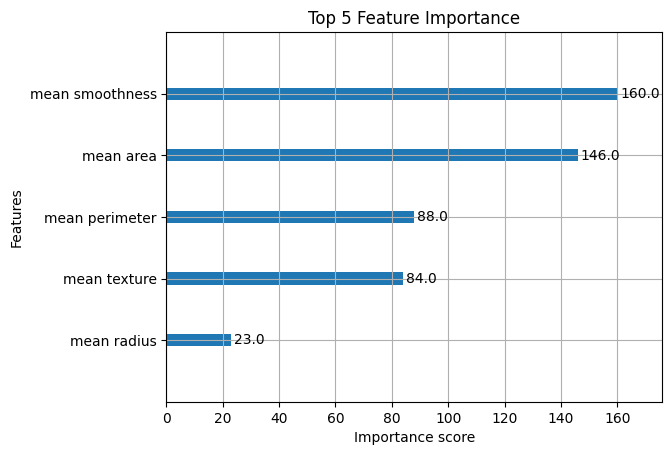

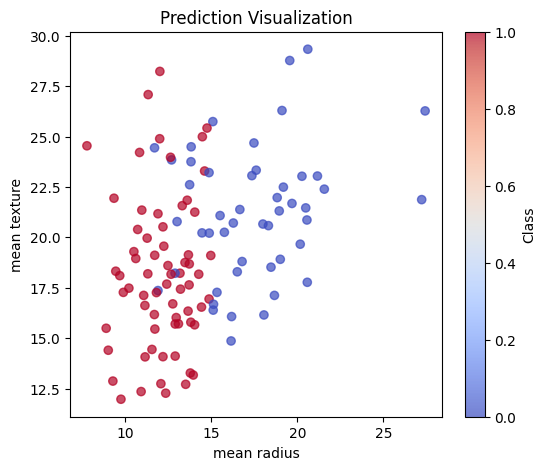

In [21]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ==========================================
# 2. Load Dataset
# ==========================================
data = load_breast_cancer()

# Select only 5 important features
selected_features = [0, 1, 2, 3, 4]

X = data.data[:, selected_features]
y = data.target

feature_names = data.feature_names[selected_features]

# Convert to DataFrame (for analysis)
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# ==========================================
# 3. Basic Insights
# ==========================================
print("Shape:", df.shape)
print("\nClass Distribution:\n", df['target'].value_counts())
print("\nStatistical Summary:\n", df.describe())

# ==========================================
# 4. Data Visualization
# ==========================================

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Boxplot (example)
sns.boxplot(x='target', y=feature_names[0], data=df)
plt.title(f"{feature_names[0]} vs Target")
plt.show()

# ==========================================
# 5. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 6. Model Training
# ==========================================
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# 7. Predictions
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# 8. Evaluation
# ==========================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred))

# ==========================================
# 9. Feature Importance
# ==========================================
plt.figure(figsize=(6,4))
xgb.plot_importance(
    model,
    max_num_features=5,
    importance_type="weight",
    show_values=True
)

plt.yticks(np.arange(5), feature_names)
plt.title("Top 5 Feature Importance")
plt.show()

# ==========================================
# 10. 2D Visualization
# ==========================================
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Prediction Visualization")

plt.colorbar(label="Class")
plt.show()